<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/segmentation_tutorial_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(40, 224, 224, 3)
(40, 224, 224, 3)
(21, 224, 224, 3)
(21, 224, 224, 3)
There are 40 training instances of size 224 x 224
There are 21 test instances of size 224 x 224


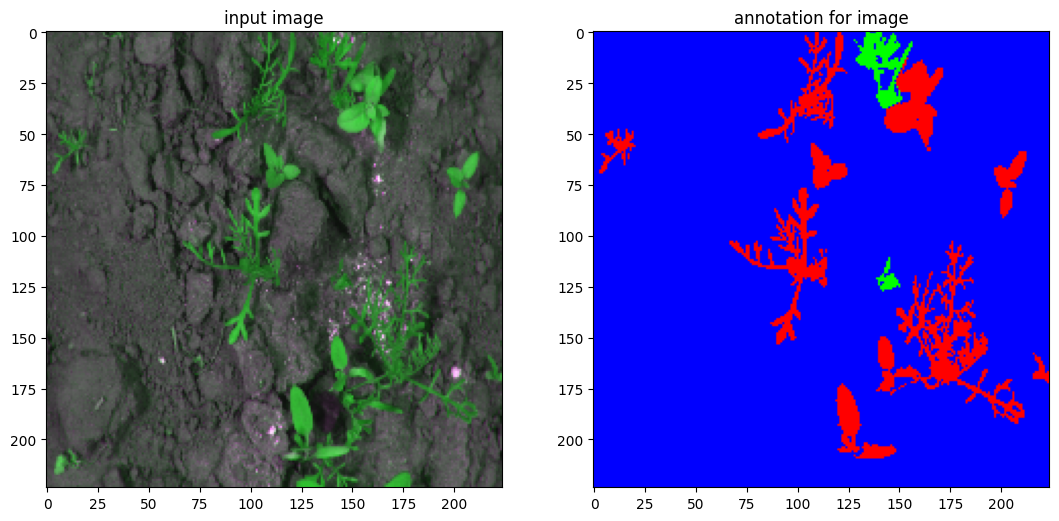

In [3]:

import numpy as np
np.random.seed(1)
from skimage.io import imread
import matplotlib.pyplot as plt
import tensorflow as tf
tf.random.set_seed(1)
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from PIL import Image


def load_segmentation_data():
  data = np.load('/content/segmentation_data.npz')
  train_x = data['train_x']
  train_y = data['train_y']
  test_x = data['test_x']
  test_y = data['test_y']
  return train_x, train_y, test_x, test_y


train_x, train_y, test_x, test_y = load_segmentation_data()

print(train_x.shape)#(40, 224, 224, 3)
print(train_y.shape)#(40, 224, 224, 3)
print(test_x.shape)#(21, 224, 224, 3)
print(test_y.shape)

print('There are %i training instances of size %i x %i' % (train_x.shape[0],train_x.shape[1],train_x.shape[2]))
print('There are %i test instances of size %i x %i' % (test_x.shape[0],test_x.shape[1],test_x.shape[2]))
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.title("input image")
plt.imshow(train_x[0,:,:,:])#plot the first image

plt.subplot(1,3,2)
plt.title("annotation for image")
plt.imshow(train_y[0,:,:,:])


In [10]:
# =========================
# U-Net model (without defining functions)
# =========================

inputs = tf.keras.layers.Input(shape=(224, 224, 3))

# 224 x 224
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
skip1 = x
x = tf.keras.layers.Conv2D(64, 3, padding="same", strides=2, activation="relu")(x)

# 112 x 112
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
skip2 = x
x = tf.keras.layers.Conv2D(128, 3, padding="same", strides=2, activation="relu")(x)

# 56 x 56
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)
skip3 = x
x = tf.keras.layers.Conv2D(256, 3, padding="same", strides=2, activation="relu")(x)

# 28 x 28
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu")(x)
skip4 = x
x = tf.keras.layers.Conv2D(512, 3, padding="same", strides=2, activation="relu")(x)

# 14 x 14 bottleneck
x = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(x)


# 14 -> 28
x = tf.keras.layers.Conv2DTranspose(512, 2, padding="same", strides=2, activation="relu")(x)
x = tf.keras.layers.Concatenate()([skip4, x])
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu")(x)

# 28 -> 56
x = tf.keras.layers.Conv2DTranspose(256, 2, padding="same", strides=2, activation="relu")(x)
x = tf.keras.layers.Concatenate()([skip3, x])
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)

# 56 -> 112
x = tf.keras.layers.Conv2DTranspose(128, 2, padding="same", strides=2, activation="relu")(x)
x = tf.keras.layers.Concatenate()([skip2, x])
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)

# 112 -> 224
x = tf.keras.layers.Conv2DTranspose(64, 2, padding="same", strides=2, activation="relu")(x)
x = tf.keras.layers.Concatenate()([skip1, x])
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)

# 224 x 224 x 3
outputs = tf.keras.layers.Conv2D(3, 1, padding="same", activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 224, 224,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 112, 112,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 112, 112,  │     73,856 │ conv2d_39[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 56, 56,    │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 56, 56,    │    295,168 │ conv2d_41[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 28, 28,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 28, 28,    │  1,180,160 │ conv2d_43[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 14, 14,    │  2,359,808 │ conv2d_44[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 14, 14,    │  4,719,616 │ conv2d_45[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 14, 14,    │  9,438,208 │ conv2d_46[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 28, 28,    │  2,097,664 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 28, 28,    │          0 │ conv2d_44[0][0],  │
│ (Concatenate)       │ 1024)             │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 28, 28,    │  4,719,104 │ concatenate_8[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 56, 56,    │    524,544 │ conv2d_48[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 56, 56,    │          0 │ conv2d_42[0][0],  │
│ (Concatenate)       │ 512)              │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 56, 56,    │  1,179,904 │ concatenate_9[0]

 Total params: 27,897,475 (106.42 MB)

 Trainable params: 27,897,475 (106.42 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step


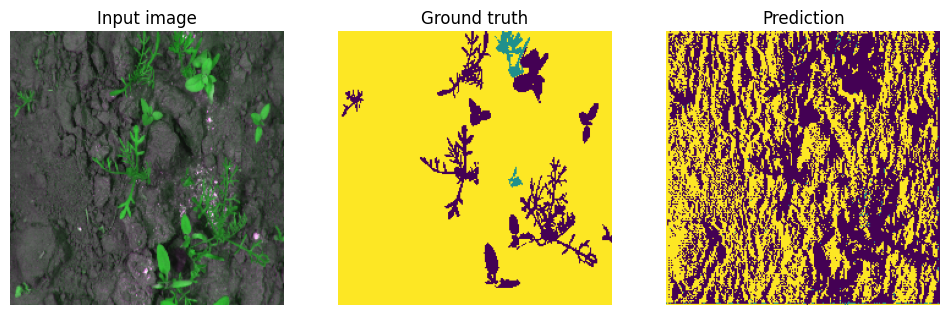

In [11]:
# =========================
# Visualize prediction
# =========================

pred = model.predict(train_x[0:1])

pred_class = tf.argmax(pred[0], axis=-1)
true_class = tf.argmax(train_y[0], axis=-1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(train_x[0])
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_class)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_class)
plt.title("Prediction")
plt.axis("off")

plt.show()

In [6]:
def encoder_block(inputs,num_filters):

  x=tf.keras.layers.Conv2D(num_filters,kernel_size=3,padding='same',strides=1, activation='relu')(inputs) #224-3 +1=222
  skip=x
  x=tf.keras.layers.Conv2D(num_filters,kernel_size=3,padding='same',strides=2, activation='relu')(x) #222-3+1=220

  return x,skip


def decoder_block(inputs,num_filters,skip_feat):

  x=tf.keras.layers.Conv2DTranspose(num_filters,kernel_size=2,padding='same',strides=2, activation='relu')(inputs)

  x=tf.keras.layers.Concatenate()([skip_feat,x])

  x=tf.keras.layers.Conv2D(num_filters,kernel_size=3,padding='same',strides=1, activation='relu')(x)
  x=tf.keras.layers.Conv2D(num_filters,kernel_size=3,padding='same',strides=1, activation='relu')(x)

  return x

def u_net(input_shape=(224,224,3),num_classes=3):
  inputs=tf.keras.layers.Input(input_shape)

  #encoder
  x,s1=encoder_block(inputs,64)
  x,s2=encoder_block(x,128)
  x,s3=encoder_block(x,256)
  x,s4=encoder_block(x,512)

  #bottleneck
  x = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(x)
  x = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(x)

  #decoder
  x=decoder_block(x,512,s4)
  x=decoder_block(x,256,s3)
  x=decoder_block(x,128,s2)
  x=decoder_block(x,64,s1)

  outputs=tf.keras.layers.Conv2D(num_classes,kernel_size=1,padding="same",activation="softmax")(x)
  model = tf.keras.Model(inputs, outputs)

  return model


model=u_net()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 112, 112,  │     73,856 │ conv2d_20[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 56, 56,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 56, 56,    │    295,168 │ conv2d_22[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 28, 28,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 28, 28,    │  1,180,160 │ conv2d_24[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 14, 14,    │  2,359,808 │ conv2d_25[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 14, 14,    │  4,719,616 │ conv2d_26[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 14, 14,    │  9,438,208 │ conv2d_27[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 28, 28,    │  2,097,664 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 28, 28,    │          0 │ conv2d_25[0][0],  │
│ (Concatenate)       │ 1024)             │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 28, 28,    │  4,719,104 │ concatenate_4[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 28, 28,    │  2,359,808 │ conv2d_29[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 56, 56,    │    524,544 │ conv2d_30[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 56, 56,    │          0 │ conv2d_23[0][0],

 Total params: 31,031,875 (118.38 MB)

 Trainable params: 31,031,875 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
first_image=train_x[0:1]
pred=model(first_image)
print(pred.shape)

(1, 224, 224, 3)


In [8]:
model.compile(optimizer='Adam', loss=tf.keras.losses.CategoricalCrossentropy)
model.fit(train_x,train_y,batch_size=8,epochs=10)

model.evaluate(test_x,test_y)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 52s 314ms/step - loss: 0.9692
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - loss: 0.4205
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - loss: 0.3170
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - loss: 0.2838
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - loss: 0.2535
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.2103
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.1703
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.1468
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - loss: 0.1345
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - loss: 0.1203
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - loss: 0.1103


0.11033158004283905

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


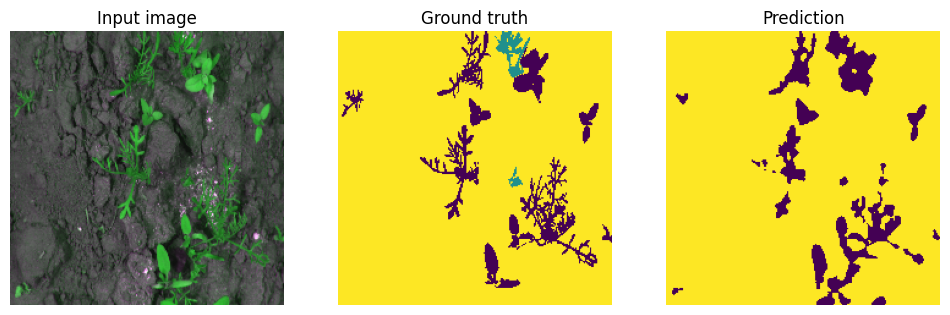

In [9]:
# =========================
# Visualize prediction
# =========================

pred = model.predict(train_x[0:1])

pred_class = tf.argmax(pred[0], axis=-1)
true_class = tf.argmax(train_y[0], axis=-1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(train_x[0])
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_class)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_class)
plt.title("Prediction")
plt.axis("off")

plt.show()